# Step 1: Import Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
!{sys.executable} -m pip install openpyxl

plt.style.use("ggplot")
%matplotlib inline


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Step 2: Load Dataset 

In [2]:
df = pd.read_excel("online_retail_II.xlsx")

# Step 3: Basic Information 

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525460,538171,21931,JUMBO STORAGE BAG SUKI,2,2010-12-09 20:01:00,1.95,17530.0,United Kingdom


In [5]:
df.shape

(525461, 8)

In [6]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [8]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


# Step 5: Missing Values 

In [9]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [10]:
(df.isnull().sum()/len(df))*100

Invoice         0.000000
StockCode       0.000000
Description     0.557225
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    20.539488
Country         0.000000
dtype: float64

# Step 6: Duplicate Rows

In [11]:
df.duplicated().sum()

np.int64(6865)

In [12]:
df[df.duplicated()]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
...,...,...,...,...,...,...,...,...
523258,538035,20728,LUNCH BAG CARS BLUE,3,2010-12-09 13:03:00,1.65,16065.0,United Kingdom
523356,538051,22659,LUNCH BOX I LOVE LONDON,2,2010-12-09 13:24:00,1.95,18041.0,United Kingdom
525170,538155,21907,I'M ON HOLIDAY METAL SIGN,1,2010-12-09 16:52:00,2.10,16907.0,United Kingdom
525293,538166,21915,RED HARMONICA IN BOX,5,2010-12-09 18:09:00,1.25,17965.0,United Kingdom


# Step 7: Revenue Column

In [13]:
df["Revenue"] = df["Quantity"] * df["Price"]

# Step 8: Top 10 Products by Quantity

In [14]:
top_quantity = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

top_quantity

Description
WHITE HANGING HEART T-LIGHT HOLDER    57733
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54698
BROCADE RING PURSE                    47647
PACK OF 72 RETRO SPOT CAKE CASES      46106
ASSORTED COLOUR BIRD ORNAMENT         44925
60 TEATIME FAIRY CAKE CASES           36326
PACK OF 60 PINK PAISLEY CAKE CASES    31822
JUMBO BAG RED RETROSPOT               30727
SMALL POPCORN HOLDER                  29500
STRAWBERRY CERAMIC TRINKET BOX        26563
Name: Quantity, dtype: int64

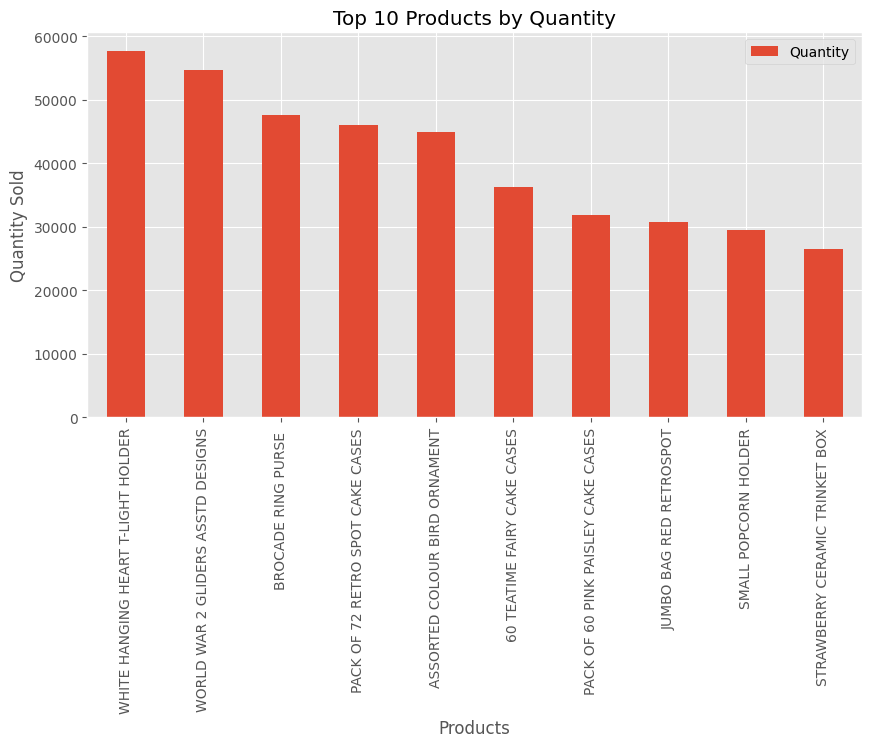

In [15]:
top_quantity.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Products by Quantity")
plt.xlabel("Products")
plt.ylabel("Quantity Sold")
plt.legend()

plt.show()

# Step 9: Top 10 Products by Revenue

In [16]:
top_revenue = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

top_revenue

Description
REGENCY CAKESTAND 3 TIER               163051.46
WHITE HANGING HEART T-LIGHT HOLDER     157865.43
DOTCOM POSTAGE                         116401.99
ASSORTED COLOUR BIRD ORNAMENT           72454.12
PAPER CHAIN KIT 50'S CHRISTMAS          57870.20
JUMBO BAG RED RETROSPOT                 56444.61
PARTY BUNTING                           49645.52
ROTATING SILVER ANGELS T-LIGHT HLDR     47672.49
POSTAGE                                 46092.36
JUMBO BAG STRAWBERRY                    36699.61
Name: Revenue, dtype: float64

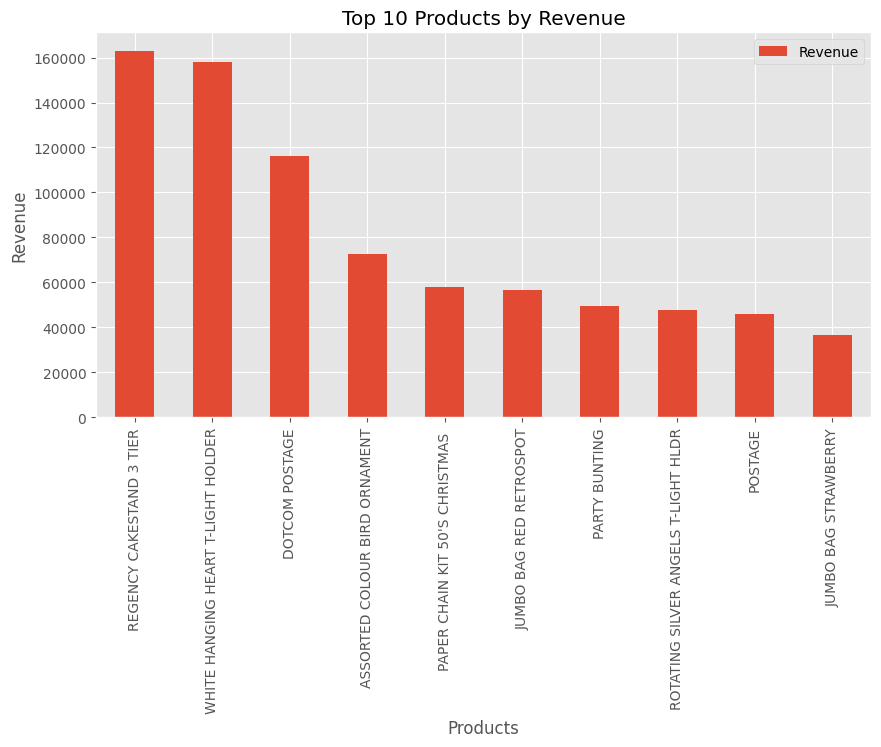

In [17]:
top_revenue.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Products by Revenue")
plt.xlabel("Products")
plt.ylabel("Revenue")
plt.legend()

plt.show()

# Step 10: Sales by Country

In [18]:
country_sales = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

country_sales.head(10)

Country
United Kingdom    8194777.533
EIRE               352242.730
Netherlands        263863.410
Germany            196290.351
France             130769.900
Sweden              51213.510
Denmark             46972.950
Switzerland         43343.410
Spain               37084.900
Australia           30051.800
Name: Revenue, dtype: float64

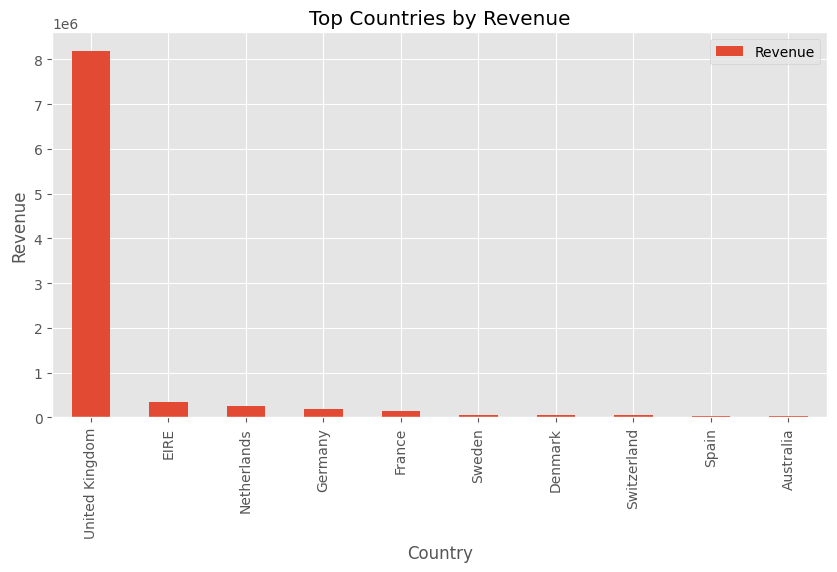

In [19]:
country_sales.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.legend()

plt.show()

# Step 11: Monthly Revenue Trend

In [21]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Month"] = df["InvoiceDate"].dt.to_period("M")
monthly = df.groupby("Month")["Revenue"].sum()

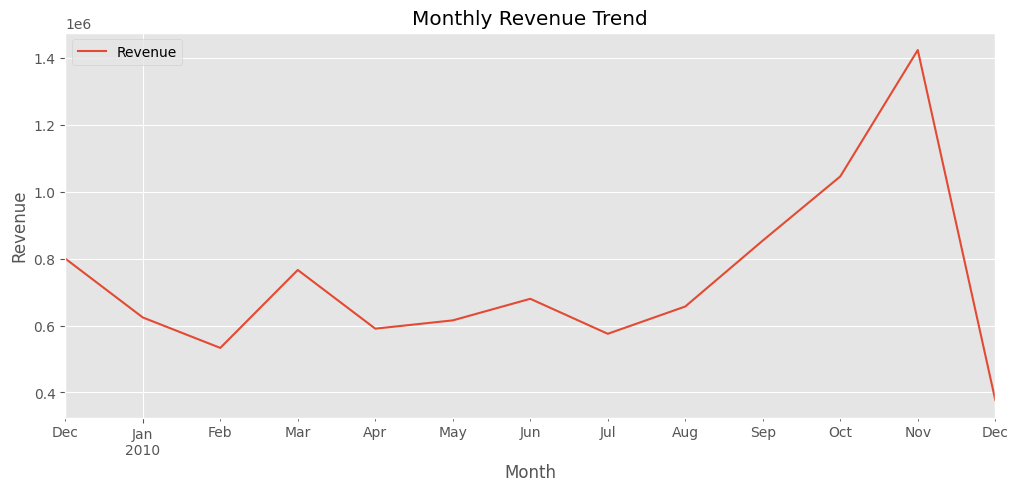

In [22]:
monthly.plot(figsize=(12,5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()

plt.show()

# Step 12: Correlation Heatmap

In [23]:
numeric = df.select_dtypes(include=np.number)

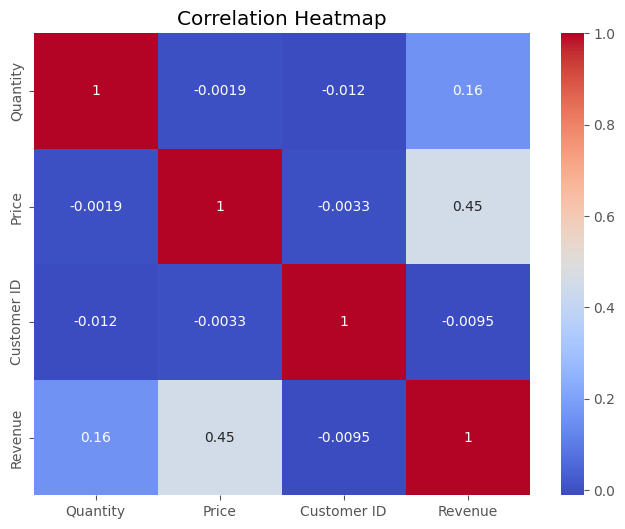

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(numeric.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")


plt.show()

# Boxplots (Outliers)

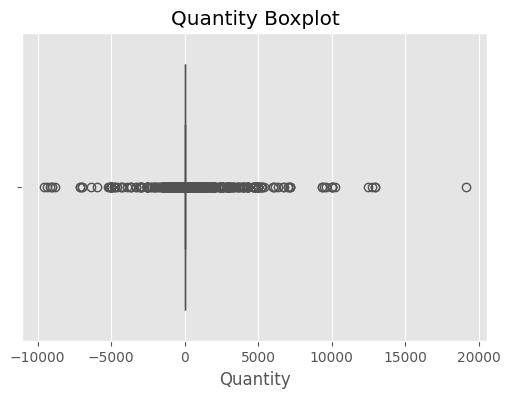

In [25]:
# Quantity
plt.figure(figsize=(6,4))

sns.boxplot(x=df["Quantity"])

plt.title("Quantity Boxplot")

plt.show()

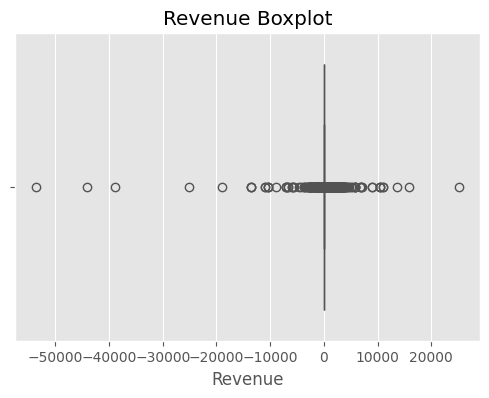

In [26]:
# Revenue
plt.figure(figsize=(6,4))

sns.boxplot(x=df["Revenue"])

plt.title("Revenue Boxplot")

plt.show()

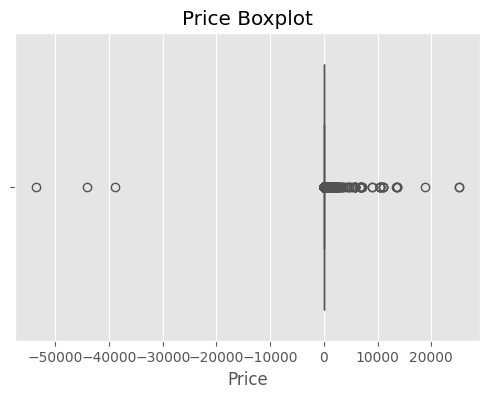

In [27]:
# Price
plt.figure(figsize=(6,4))

sns.boxplot(x=df["Price"])

plt.title("Price Boxplot")

plt.show()

# Business Insights

1. The United Kingdom generated the highest revenue (8,194,777.53), making it the company's largest market by a significant margin.

2. The product "WHITE HANGING HEART T-LIGHT HOLDER" was the best-selling product by quantity (57,733 units), indicating very high customer demand.

3. "REGENCY CAKESTAND 3 TIER" generated the highest revenue (£163,051.46), showing that products with higher prices can contribute more revenue even if they are not sold in the highest quantities.

4. Countries such as EIRE, Netherlands, Germany, and France are the company's strongest international markets after the United Kingdom.

5. The dataset contains 107,927 missing Customer ID values, 2,928 missing product descriptions, and 6,865 duplicate records. These data quality issues should be addressed before building predictive or recommendation models.